In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install adversarial-robustness-toolbox

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# Loading the data

In [ ]:
data_path = "/content/drive/MyDrive/UNSW_NB15_training-set/"

In [ ]:
# Load the data into pandas dataframes
train_df = pd.read_csv(data_path + "UNSW_NB15_train.csv")
test_df = pd.read_csv(data_path + "UNSW_NB15_test.csv")

# Print the first 5 rows of the train data
train_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,...,1,1,0,0,0,1,1,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,...,1,2,0,0,0,1,6,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,...,1,3,0,0,0,2,6,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,...,1,3,1,1,0,2,1,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
print("Shape of the training data", train_df.shape)
print("Number of data points", train_df.shape[0])
print("Number of features",train_df.shape[1])

Shape of the training data (175341, 44)
Number of data points 175341
Number of features 44


In [ ]:
print("Shape of the testing data", test_df.shape)
print("Number of data points", test_df.shape[0])
print("Number of features",test_df.shape[1])

Shape of the testing data (82332, 44)
Number of data points 82332
Number of features 44


# Data exploration

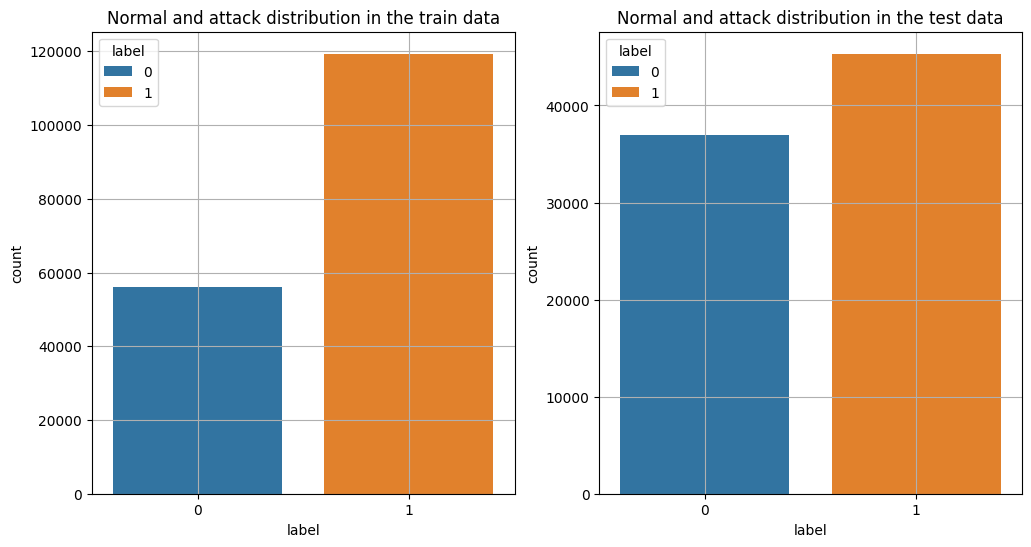

In [ ]:
# Plot the distributions of normal class 0 and attack class 1
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(x ='label' , data =train_df, hue='label')
plt.title("Normal and attack distribution in the train data")
plt.grid()
plt.subplot(1,2,2)
sns.countplot(x ='label' , data=test_df, hue ='label')
plt.title("Normal and attack distribution in the test data")
plt.grid()
plt.show()

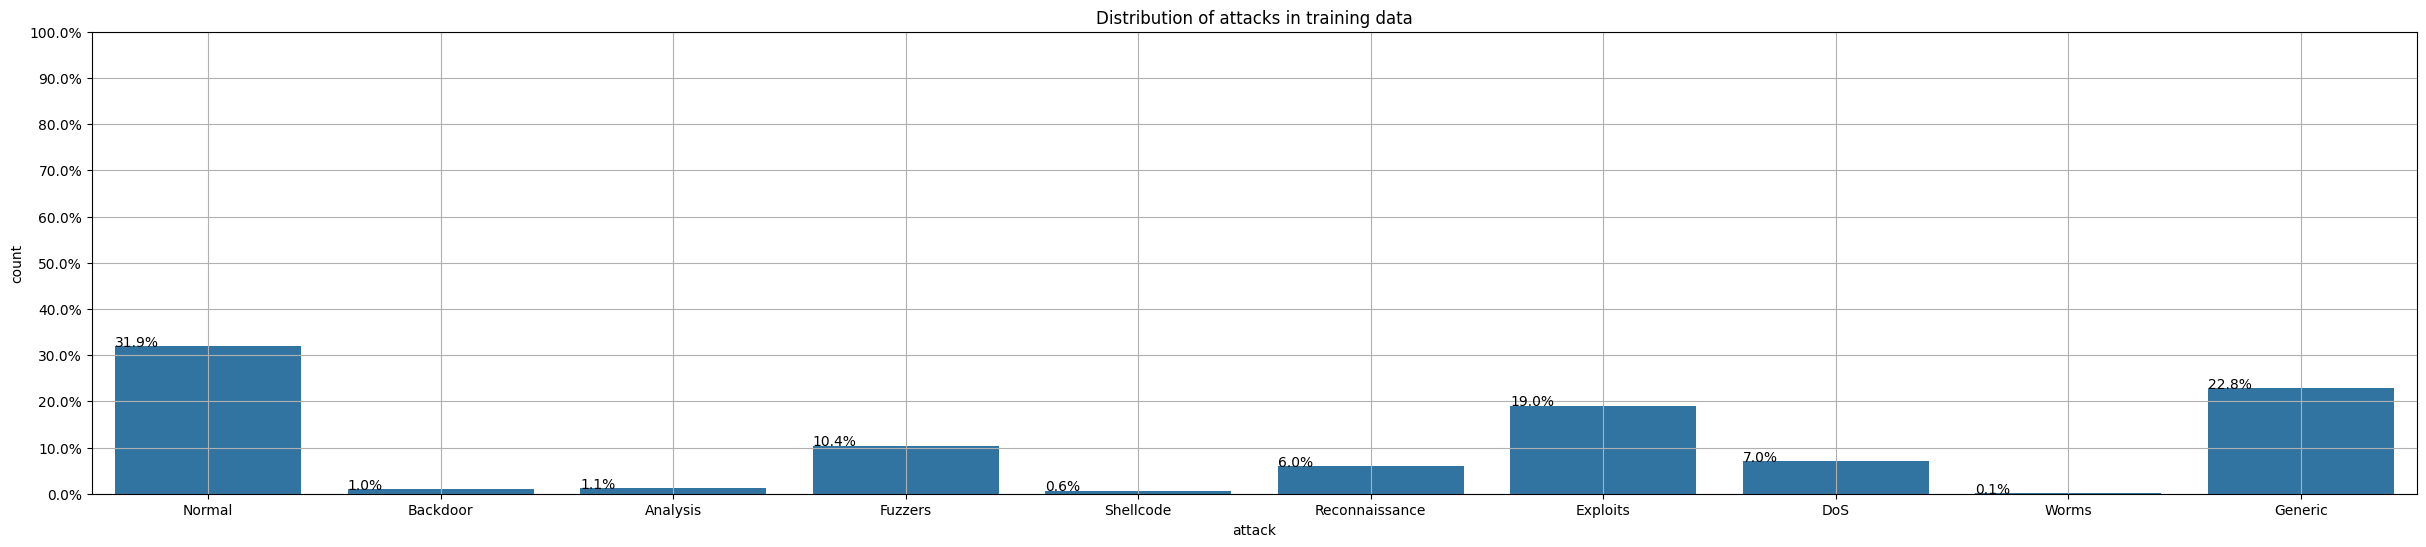

In [ ]:
# Plot the distribution of all attacks in the train data
f, ax = plt.subplots(figsize=(30,6))
# Plot the data counts per attack (there are 23 attack classes)
ax = sns.countplot(x="attack", data=train_df)
# The total number of rows
total = len(train_df) * 1
# Plot bars for each attack
for p in ax.patches:
   ax.annotate('{:.1f}%'.format(100*p.get_height()/total), (p.get_x(), p.get_height()))
# Set axis ticks and thicklabels
ax.yaxis.set_ticks(np.linspace(0, total, 11))
ax.set_yticklabels(map('{:.1f}%'.format, 100*ax.yaxis.get_majorticklocs()/total))

plt.title("Distribution of attacks in training data")
plt.grid()
plt.show()

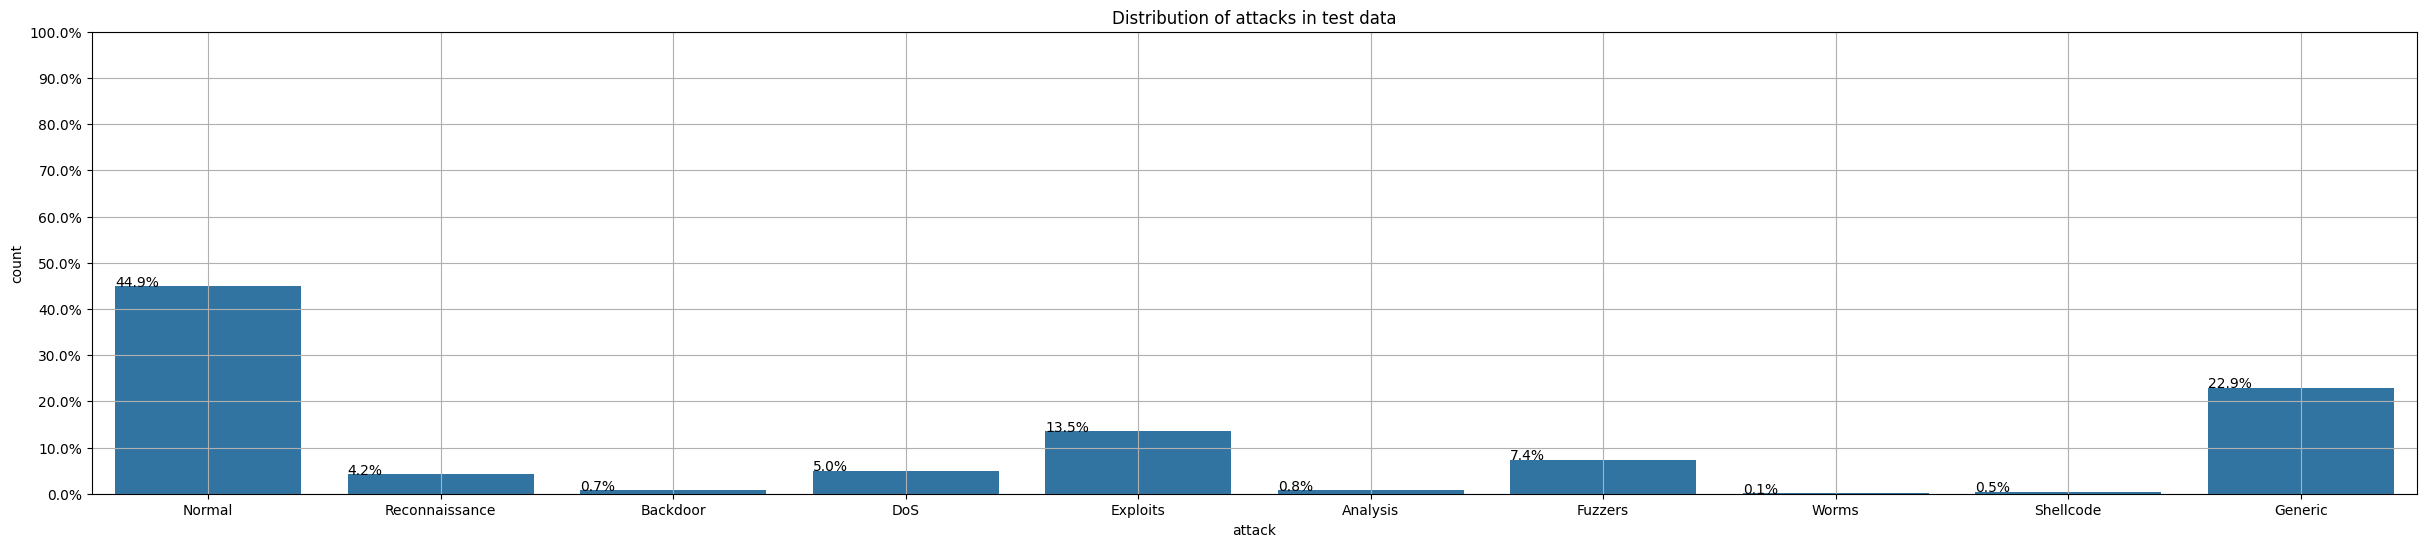

In [ ]:
# And plot the distribution of all attacks in the test data
f, ax = plt.subplots(figsize=(30,6))
# Plot the data counts per attack (there are 23 attack classes)
ax = sns.countplot(x="attack", data=test_df)
# The total number of rows
total = len(test_df) * 1
# Plot bars for each attack
for p in ax.patches:
   ax.annotate('{:.1f}%'.format(100*p.get_height()/total), (p.get_x(), p.get_height()))
# Set axis ticks and thicklabels
ax.yaxis.set_ticks(np.linspace(0, total, 11))
ax.set_yticklabels(map('{:.1f}%'.format, 100*ax.yaxis.get_majorticklocs()/total))

plt.title("Distribution of attacks in test data")
plt.grid()
plt.show()

In [ ]:
# Print the sorted number of datapoints belonging to each attack class
train_class_distribution = train_df['attack'].value_counts()

# Sorting them in decreasing order (by number of datapoints)
sorted_yi = np.argsort(-train_class_distribution.values)
# Printing the number of datapoints and the percetange
for i in sorted_yi:
    print('Number of data points in class', i+1, ':',train_class_distribution.values[i], '(', np.round((train_class_distribution.values[i]/len(train_df)*100), 3), '%)')

Number of data points in class 1 : 56000 ( 31.938 %)
Number of data points in class 2 : 40000 ( 22.813 %)
Number of data points in class 3 : 33393 ( 19.045 %)
Number of data points in class 4 : 18184 ( 10.371 %)
Number of data points in class 5 : 12264 ( 6.994 %)
Number of data points in class 6 : 10491 ( 5.983 %)
Number of data points in class 7 : 2000 ( 1.141 %)
Number of data points in class 8 : 1746 ( 0.996 %)
Number of data points in class 9 : 1133 ( 0.646 %)
Number of data points in class 10 : 130 ( 0.074 %)


In [ ]:
# Repeat the same for the test data
test_class_distribution = test_df['attack'].value_counts()

# Sorting them in decreasing order (by number of datapoints)
sorted_yi = np.argsort(-test_class_distribution.values)
# Printing the number of datapoints and the percetange
for i in sorted_yi:
    print('Number of data points in class', i+1, ':',test_class_distribution.values[i], '(', np.round((test_class_distribution.values[i]/len(test_df)*100), 3), '%)')

Number of data points in class 1 : 37000 ( 44.94 %)
Number of data points in class 2 : 18871 ( 22.921 %)
Number of data points in class 3 : 11132 ( 13.521 %)
Number of data points in class 4 : 6062 ( 7.363 %)
Number of data points in class 5 : 4089 ( 4.966 %)
Number of data points in class 6 : 3496 ( 4.246 %)
Number of data points in class 7 : 677 ( 0.822 %)
Number of data points in class 8 : 583 ( 0.708 %)
Number of data points in class 9 : 378 ( 0.459 %)
Number of data points in class 10 : 44 ( 0.053 %)


In [ ]:
# The dataset have attacks that are present in the test set and not in the train set
# Print those attacks

trn = set(train_df['attack'].unique())
tst = set(test_df['attack'].unique())

extra = tst - trn

print(extra)
print("*"*100)
print("Number of extra attacks that are present only in the test set:", len(extra))

set()
****************************************************************************************************
Number of extra attacks that are present only in the test set: 0


# Convert categorical columns into numerical values

In [ ]:
# Display the columns and the datatype for each column
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                175341 non-null  float64
 1   proto              175341 non-null  object 
 2   service            175341 non-null  object 
 3   state              175341 non-null  object 
 4   spkts              175341 non-null  int64  
 5   dpkts              175341 non-null  int64  
 6   sbytes             175341 non-null  int64  
 7   dbytes             175341 non-null  int64  
 8   rate               175341 non-null  float64
 9   sttl               175341 non-null  int64  
 10  dttl               175341 non-null  int64  
 11  sload              175341 non-null  float64
 12  dload              175341 non-null  float64
 13  sloss              175341 non-null  int64  
 14  dloss              175341 non-null  int64  
 15  sinpkt             175341 non-null  float64
 16  di

In [ ]:
print(train_df.columns.tolist())


['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack', 'label']


In [ ]:
# Convert the columns with categorical values into numerical values
from sklearn.preprocessing import OrdinalEncoder

categs_feats = train_df[['dur', 'proto', 'service', 'state']]
encoder = OrdinalEncoder()
categs_encoded = encoder.fit_transform(categs_feats)

In [ ]:
train_df[['dur', 'proto', 'service', 'state']] = pd.DataFrame(categs_encoded, columns=categs_feats.columns, index=categs_feats.index)
train_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack,label
0,15290.0,113.0,0.0,2.0,6,4,258,172,74.087490,252,...,1,1,0,0,0,1,1,0,Normal,0
1,36287.0,113.0,0.0,2.0,14,38,734,42014,78.473372,62,...,1,2,0,0,0,1,6,0,Normal,0
2,61852.0,113.0,0.0,2.0,8,16,364,13186,14.170161,62,...,1,3,0,0,0,2,6,0,Normal,0
3,62406.0,113.0,3.0,2.0,12,12,628,770,13.677108,62,...,1,3,1,1,0,2,1,0,Normal,0
4,27655.0,113.0,0.0,2.0,10,6,534,268,33.373826,254,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
# Create a training dataset
X_train = train_df.drop(['is_sm_ips_ports', 'attack', 'label'], axis=1)
y_train = train_df['label']

In [ ]:
# Repeat the same for the test dataset
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dur                82332 non-null  float64
 1   proto              82332 non-null  object 
 2   service            82332 non-null  object 
 3   state              82332 non-null  object 
 4   spkts              82332 non-null  int64  
 5   dpkts              82332 non-null  int64  
 6   sbytes             82332 non-null  int64  
 7   dbytes             82332 non-null  int64  
 8   rate               82332 non-null  float64
 9   sttl               82332 non-null  int64  
 10  dttl               82332 non-null  int64  
 11  sload              82332 non-null  float64
 12  dload              82332 non-null  float64
 13  sloss              82332 non-null  int64  
 14  dloss              82332 non-null  int64  
 15  sinpkt             82332 non-null  float64
 16  dinpkt             823

In [ ]:
categs_feats = test_df[['dur', 'proto', 'service', 'state']]
encoder = OrdinalEncoder()
categs_encoded = encoder.fit_transform(categs_feats)

In [ ]:
test_df[['dur', 'proto', 'service', 'state']] = pd.DataFrame(categs_encoded, columns=categs_feats.columns, index=categs_feats.index)
test_df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack,label
0,11.0,117.0,0.0,4.0,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,8.0,117.0,0.0,4.0,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,5.0,117.0,0.0,4.0,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0
3,6.0,117.0,0.0,4.0,2,0,900,0,166666.6608,254,...,1,3,0,0,0,2,3,0,Normal,0
4,10.0,117.0,0.0,4.0,2,0,2126,0,100000.0025,254,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
# Create a test dataset
X_test = test_df.drop(['is_sm_ips_ports', 'attack', 'label'], axis=1)
y_test = test_df['label']

# Normalize the data values in each column to the range [0,1]

In [ ]:
# Standardize features by scaling each feature to range [0, 1]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Note: the variables are now numpy arrays, and not pandas dataframes
print('Data type:', type(X_train))

# Display the shapes of train and test datasets
print('\nTrain shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

# Display the range to make sure they are in the [0, 1] range
print('\nMax value', np.max(X_train))
print('Min value', np.min(X_train))
print('Average value', np.mean(X_train))

Data type: <class 'numpy.ndarray'>

Train shape: (175341, 41)
Test shape: (82332, 41)

Max value 1.0000000000000002
Min value 0.0
Average value 0.12756220004483595


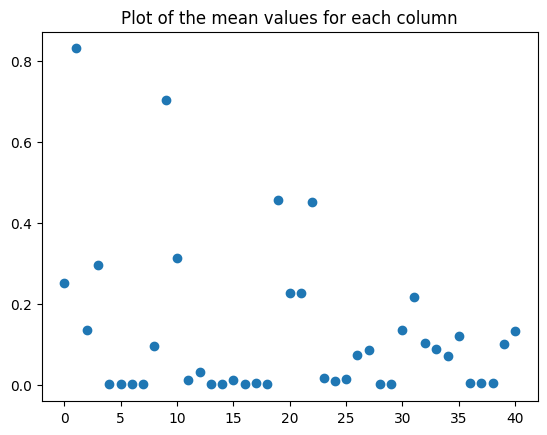

In [ ]:
# Let's examine the mean values for each of the columns
plt.plot(np.mean(X_train, axis=0), 'o')
plt.title("Plot of the mean values for each column")
plt.show()

# classify the network connections into normal and attack classes

In [ ]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn import neighbors
from sklearn.naive_bayes import GaussianNB

In [ ]:
print('LOGISTIC REGRESSION')
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

print('Accuracy:', model_lr.score(X_test, y_test))

LOGISTIC REGRESSION
Accuracy: 0.7924379342175581


In [ ]:
print('*** DECISION TREE ***')
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

print('Accuracy:', model_dt.score(X_test, y_test))

*** DECISION TREE ***
Accuracy: 0.8430986736627314


In [ ]:
print('*** RANDOM FOREST ***')
model_rf = RandomForestClassifier(verbose=0, warm_start=True)
model_rf.fit(X_train, y_train)

print('Accuracy:', model_rf.score(X_test, y_test))

*** RANDOM FOREST ***
Accuracy: 0.8670383326045766


In [ ]:
print('*** K-NEAREST NEIGHBORS ***')
model_dt = KNeighborsClassifier()
model_dt.fit(X_train, y_train)

print('Accuracy:', model_dt.score(X_test, y_test))

*** K-NEAREST NEIGHBORS ***
Accuracy: 0.8269445659039013


In [ ]:
print('*** NAIVE BAYES ***')
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

print('Accuracy:', model_nb.score(X_test, y_test))

*** NAIVE BAYES ***
Accuracy: 0.7533522810085993


In [ ]:
print('*** Support Vector Machines ***')

model_svm = LinearSVC(max_iter=10000)
model_svm.fit(X_train, y_train)

print('Accuracy:', model_svm.score(X_test, y_test))

*** Support Vector Machines ***
Accuracy: 0.7995918962250401


# Deep NN

In [ ]:
import tensorflow
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import datetime
now = datetime.datetime.now

In [ ]:
# Define the layers for the network
input_seq = Input(shape=(41,))

hidden = Dense(1024, activation='relu')(input_seq)
hidden = Dropout(0.25)(hidden)
hidden = Dense(512, activation='relu')(hidden)
hidden = Dropout(0.25)(hidden)
hidden = Dense(256, activation='relu')(hidden)
hidden = Dropout(0.25)(hidden)
predictions = Dense(2, activation='softmax')(hidden)

# The model
model = Model(inputs=input_seq, outputs=predictions)

In [ ]:
model.compile(optimizer=Adam(learning_rate = 1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Training time: 0:04:57.202462


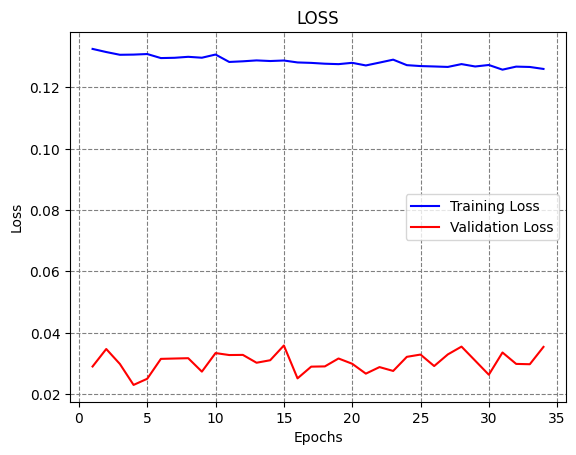

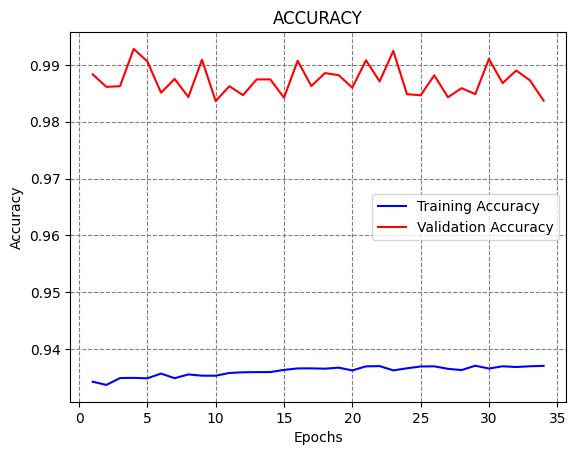

In [ ]:
# Fit model
t = now()
callbacks = [EarlyStopping(monitor='val_accuracy', patience=30)]
history = model.fit(X_train, y_train, batch_size=64, epochs=300,
                     validation_split=0.2, verbose=0, callbacks=callbacks)

print('Training time: %s' % (now() - t))

# Plot the loss and accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1,1)
plt.plot(epochsn,train_loss, 'b', label='Training Loss')
plt.plot(epochsn,val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.figure()
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# obtain test accuracy greater than 85%.

In [ ]:
# Evaluate on test data
evals_test = model.evaluate(X_test, y_test)
print("Classification Accuracy: ", evals_test[1])

2573/2573 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9537 - loss: 0.1044
Classification Accuracy:  0.85468590259552


#Task 3: Step 1.

In [ ]:
# Creating adversarial test sets of 1000 samples

# Define a random seed (to draw the same smamples)
np.random.seed(2)

ind = np.random.randint(1, 20000, 1000)

# Set of image for testing the attacks
adv_test_data = X_test[ind]
adv_test_labels = y_test[ind]

In [ ]:
from art.estimators.classification import TensorFlowV2Classifier
from art.attacks.evasion import FastGradientMethod

In [ ]:
classifier = TensorFlowV2Classifier(model=model, nb_classes=2,
                                    clip_values=(0, 1), input_shape=(42,), loss_object=tensorflow.keras.losses.SparseCategoricalCrossentropy())

# Apply the following perturbation magnitudes: 𝜖= [0.01, 0.025, 0.05, 0.1, 0.2,0.3,0.5].

In [ ]:
# FGSM attack
epsilon = [0.01, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5]

fgsm_attack_acc = []
for eps in epsilon:
    attack_fgsm = FastGradientMethod(estimator=classifier, eps=eps)
    fgsm_attack_adv_data = attack_fgsm.generate(adv_test_data)
    loss_test, accuracy_test = model.evaluate(fgsm_attack_adv_data, adv_test_labels)
    fgsm_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((fgsm_attack_adv_data - adv_test_data)))
    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9587 - loss: 0.1118
Accuracy on adversarial test data: 96.30%
Average perturbation: 0.01
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8601 - loss: 0.3662
Accuracy on adversarial test data: 87.70%
Average perturbation: 0.01
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8366 - loss: 0.6320
Accuracy on adversarial test data: 84.80%
Average perturbation: 0.02
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8634 - loss: 0.9927
Accuracy on adversarial test data: 86.80%
Average perturbation: 0.05
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7871 - loss: 2.6273
Accuracy on adversarial test data: 79.30%
Average perturbation: 0.09
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7894 - loss: 7.1324
Accuracy on adversarial test data: 79.80%
Average perturbation: 0.13
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7301 - loss: 28.5381
Accuracy on adversarial test data: 73.60%
Average perturbation: 0.21


In [ ]:
# Create adversarail samples and display them
attack_fgsm = FastGradientMethod(estimator=classifier, eps=0.1)
fgsm_attack_adv_data = attack_fgsm.generate(adv_test_data)

np.set_printoptions(precision=2, suppress=True)
print("First test example:", adv_test_data[0])
print("\nFirst advesarial example:", fgsm_attack_adv_data[0])

First test example: [0.03 0.89 0.   0.25 0.   0.   0.   0.   0.   1.   0.24 0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.04
 0.   0.   0.02 0.   0.02 0.   0.   0.02 0.   0.   0.   0.02 0.02]

First advesarial example: [0.   0.79 0.   0.35 0.   0.1  0.1  0.1  0.   0.9  0.14 0.1  0.1  0.1
 0.1  0.1  0.   0.   0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.14 0.14
 0.   0.   0.12 0.1  0.   0.1  0.   0.   0.   0.   0.   0.   0.  ]


In [ ]:
# Second adversarial sample
np.set_printoptions(precision=2, suppress=True)
print("Second test example:", adv_test_data[1])
print("\nSecond advesarial example:", fgsm_attack_adv_data[1])

Second test example: [0.   0.06 0.   0.5  0.   0.   0.   0.   0.33 1.   0.   0.04 0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.
 0.   0.   0.15 0.33 0.18 0.18 0.2  0.14 0.   0.   0.   0.15 0.15]

Second advesarial example: [0.   0.16 0.   0.6  0.   0.   0.   0.   0.23 0.9  0.   0.   0.   0.
 0.   0.1  0.   0.1  0.   0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.14 0.
 0.   0.   0.25 0.23 0.08 0.28 0.1  0.04 0.   0.   0.   0.25 0.05]


# Step02: Implement a non-targeted white-box JSMA

In [ ]:
from art.attacks.evasion import SaliencyMapMethod

In [ ]:
# JSMA attack
theta_gamma_params = [(0.05, 0.1),(0.1, 0.3),(0.2, 0.2),(0.3, 0.1),(0.4, 0.05),(0.25, 0.4),(0.5, 0.5)]

jsma_attack_acc = []
for theta, gamma in theta_gamma_params:
    attack_jsma = SaliencyMapMethod(
        classifier=classifier,
        theta=theta,
        gamma=gamma,
        batch_size=128
    )
    jsma_attack_adv_data = attack_jsma.generate(adv_test_data)
    loss_test, accuracy_test = model.evaluate(jsma_attack_adv_data, adv_test_labels)
    jsma_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((jsma_attack_adv_data - adv_test_data)))
    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))
    print(f'Parameters: theta={theta}, gamma={gamma}\n')

JSMA:   0%|          | 0/8 [00:00<?, ?it/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6333 - loss: 0.7090
Accuracy on adversarial test data: 62.90%
Average perturbation: 0.02
Parameters: theta=0.05, gamma=0.1



JSMA:   0%|          | 0/8 [00:00<?, ?it/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2271 - loss: 1.3287
Accuracy on adversarial test data: 21.90%
Average perturbation: 0.06
Parameters: theta=0.1, gamma=0.3



JSMA:   0%|          | 0/8 [00:00<?, ?it/s]

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5376 - loss: 3.1778
Accuracy on adversarial test data: 54.60%
Average perturbation: 0.03
Parameters: theta=0.4, gamma=0.05



JSMA:   0%|          | 0/8 [00:00<?, ?it/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2186 - loss: 3.2891
Accuracy on adversarial test data: 21.00%
Average perturbation: 0.09
Parameters: theta=0.25, gamma=0.4



JSMA:   0%|          | 0/8 [00:00<?, ?it/s]

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2315 - loss: 9.8576
Accuracy on adversarial test data: 22.60%
Average perturbation: 0.13
Parameters: theta=0.5, gamma=0.5



In [ ]:
# Create adversarial samples using JSMA and display them
attack_jsma = SaliencyMapMethod(
    classifier=classifier,
    theta=0.3,
    gamma=0.3,
    batch_size=128
)
jsma_attack_adv_data = attack_jsma.generate(adv_test_data)

np.set_printoptions(precision=2, suppress=True)
print("First test example:", adv_test_data[0])
print("\nFirst adversarial example (JSMA):", jsma_attack_adv_data[0])


JSMA:   0%|          | 0/8 [00:00<?, ?it/s]

First test example: [0.03 0.89 0.   0.25 0.   0.   0.   0.   0.   1.   0.24 0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.04
 0.   0.   0.02 0.   0.02 0.   0.   0.02 0.   0.   0.   0.02 0.02]

First adversarial example (JSMA): [0.03 0.89 0.   0.25 0.   0.   0.   0.   0.   1.   0.24 0.   0.3  0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.34
 0.   0.   0.32 0.   0.02 0.3  0.   0.32 0.   0.   0.   0.02 0.32]


In [ ]:
np.set_printoptions(precision=2, suppress=True)
print("\n\nSecond test example:", adv_test_data[1])
print("\nSecond adversarial example (JSMA):", jsma_attack_adv_data[1])





Second test example: [0.   0.06 0.   0.5  0.   0.   0.   0.   0.33 1.   0.   0.04 0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.
 0.   0.   0.15 0.33 0.18 0.18 0.2  0.14 0.   0.   0.   0.15 0.15]

Second adversarial example (JSMA): [0.   0.36 0.   0.5  0.   0.   0.   0.   0.33 1.   0.   0.04 0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.34 0.
 0.   0.   0.45 0.33 0.18 0.48 0.2  0.14 0.   0.   0.   0.15 0.15]


# Step 3: non-targeted white-box FGSM

In [ ]:
# Creating adversarial test sets of 1000 samples

# Define a random seed (to draw the same smamples)
np.random.seed(2)

ind = np.random.randint(1, 20000, 1000)

# Set of image for testing the attacks
adv_test_data = X_test[ind]
adv_test_labels = y_test[ind]

In [ ]:
import numpy as np
from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import FastGradientMethod

from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# 2. Create ART classifier wrapper
logreg_classifier = SklearnClassifier(
    model=model,
    clip_values=(0, 1)  # Adjust if your data has different scale
)

In [ ]:
# FGSM attack on Logistic Regression
epsilon = [0.01, 0.025, 0.05, 0.1, 0.2, 0.3, 0.5]

fgsm_attack_acc = []
for eps in epsilon:
    attack_fgsm = FastGradientMethod(estimator=logreg_classifier, eps=eps)
    fgsm_attack_adv_data = attack_fgsm.generate(adv_test_data)
    accuracy_test = model.score(fgsm_attack_adv_data, adv_test_labels)
    fgsm_attack_acc.append(accuracy_test)
    perturbation = np.mean(np.abs((fgsm_attack_adv_data - adv_test_data)))
    print('Accuracy on adversarial test data: {:4.2f}%'.format(accuracy_test * 100))
    print('Average perturbation: {:4.2f}'.format(perturbation))



Accuracy on adversarial test data: 98.40%
Average perturbation: 0.01
Accuracy on adversarial test data: 86.60%
Average perturbation: 0.02
Accuracy on adversarial test data: 44.50%
Average perturbation: 0.03
Accuracy on adversarial test data: 2.40%
Average perturbation: 0.06
Accuracy on adversarial test data: 1.20%
Average perturbation: 0.12
Accuracy on adversarial test data: 1.20%
Average perturbation: 0.18
Accuracy on adversarial test data: 1.20%
Average perturbation: 0.28


In [ ]:
#Adversarial First example
attack_fgsm = FastGradientMethod(estimator=logreg_classifier, eps=0.1)
fgsm_attack_adv_data = attack_fgsm.generate(adv_test_data)

np.set_printoptions(precision=2, suppress=True)
print("\nFirst test example:", adv_test_data[0])
print("First adversarial example:", fgsm_attack_adv_data[0])
print("Difference:", fgsm_attack_adv_data[0] - adv_test_data[0])


First test example: [0.03 0.89 0.   0.25 0.   0.   0.   0.   0.   1.   0.24 0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.04
 0.   0.   0.02 0.   0.02 0.   0.   0.02 0.   0.   0.   0.02 0.02]
First adversarial example: [0.   0.99 0.   0.15 0.   0.   0.   0.1  0.   0.9  0.14 0.1  0.1  0.
 0.1  0.1  0.1  0.   0.   0.1  0.1  0.   0.   0.1  0.1  0.1  0.14 0.
 0.1  0.1  0.12 0.   0.   0.   0.   0.   0.   0.   0.1  0.   0.12]
Difference: [-0.03  0.1   0.   -0.1  -0.   -0.   -0.    0.1  -0.   -0.1  -0.1   0.1
  0.1   0.    0.1   0.1   0.1   0.    0.    0.1   0.1   0.    0.    0.1
  0.1   0.1   0.1  -0.04  0.1   0.1   0.1   0.   -0.02  0.    0.   -0.02
  0.    0.    0.1  -0.02  0.1 ]


In [ ]:
#Adversarial Second example
print("\nSecond test example:", adv_test_data[1])
print("Second adversarial example:", fgsm_attack_adv_data[1])
print("Difference:", fgsm_attack_adv_data[1] - adv_test_data[1])


Second test example: [0.   0.06 0.   0.5  0.   0.   0.   0.   0.33 1.   0.   0.04 0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.
 0.   0.   0.15 0.33 0.18 0.18 0.2  0.14 0.   0.   0.   0.15 0.15]
Second adversarial example: [0.   0.16 0.   0.4  0.   0.   0.   0.1  0.23 0.9  0.   0.14 0.1  0.
 0.1  0.1  0.1  0.   0.   0.1  0.1  0.   0.   0.1  0.1  0.1  0.14 0.
 0.1  0.1  0.25 0.23 0.08 0.08 0.1  0.04 0.   0.   0.1  0.05 0.25]
Difference: [-0.   0.1  0.  -0.1 -0.   0.  -0.   0.1 -0.1 -0.1  0.   0.1  0.1  0.
  0.1  0.1  0.1  0.   0.   0.1  0.1  0.   0.   0.1  0.1  0.1  0.1  0.
  0.1  0.1  0.1 -0.1 -0.1 -0.1 -0.1 -0.1  0.   0.   0.1 -0.1  0.1]
